# LIBERO Object checkpoint-20k failure analysis

This notebook-script diagnoses the completed B0 LIBERO run at three levels:

1. Existing training and rollout evidence across checkpoints.
2. Teacher-forced validation: cached ground-truth action chunks versus sampled
   checkpoint predictions, including gripper commands and transitions.
3. Paired simulator replay: start from an exact demonstration simulator state,
   execute either the predicted or demonstrated ten-action chunk, and compare
   the resulting robot state with the recorded demonstration state.

The primary artifact is `analyze_libero_object_checkpoint20k.ipynb`. This
percent-format source is kept beside it so the analysis remains easy to diff.
Running the whole source file is also supported:

    uv run --no-sync python notebooks/analyze_libero_object_checkpoint20k.py

The GPU-heavy cells use cached Qwen and T5 features, so they load only RDT-1B
and frozen SigLIP. They do not load Qwen or T5 XXL.

In [ ]:
from __future__ import annotations

import gc
import json
import math
import os
import random
import sys
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable

os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/thinkflow-cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/thinkflow-matplotlib")
os.environ.setdefault("HF_HOME", os.path.expanduser("~/.cache/huggingface"))

import h5py
import cv2
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import torch

def find_repo_root() -> Path:
    """Resolve the repository in both Python-script and Jupyter execution."""
    candidates: list[Path] = []
    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parents[1])
    working_directory = Path.cwd().resolve()
    candidates.extend([working_directory, *working_directory.parents])
    for candidate in candidates:
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "src/thinkflow_rdt"
        ).is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside ThinkFlow-RDT-1B")


REPO_ROOT = find_repo_root()
for import_root in (REPO_ROOT / "src", REPO_ROOT / "scripts"):
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

from evaluate_libero_rdt import native_rdt_action_to_libero_10d  # noqa: E402
from rollout_libero_rdt import install_robosuite_mujoco_compatibility  # noqa: E402
from thinkflow_rdt.adapters.libero import (  # noqa: E402
    convert_libero_demo,
    libero_observation_to_rdt,
    ortho6d_to_rotation_matrix,
    rdt_action_to_libero,
)
from thinkflow_rdt.checkpoint import load_trainable_artifact  # noqa: E402
from thinkflow_rdt.config import load_config  # noqa: E402
from thinkflow_rdt.data import (  # noqa: E402
    ONLINE_SIGLIP_REQUIRED_KEYS,
    CachedFeatureDataset,
    RDTOnlineSiglipBatchCollator,
)
from thinkflow_rdt.model import SFTConditionedRDT  # noqa: E402
from thinkflow_rdt.train import add_online_siglip_features, load_online_siglip  # noqa: E402

## Configuration

`OFFLINE_SAMPLE_COUNT=320` gives 32 samples per LIBERO Object task when the
validation cache has enough candidates. `PAIRED_PROBES_PER_TASK=1` performs
ten exact-state simulator probes, each executing ten commands. Increase these
values only after the first complete run.

In [ ]:
CHECKPOINT = REPO_ROOT / "output_2/libero_b0_from_oxe20k_v2/checkpoint-20000"
RUN_ROOT = CHECKPOINT.parent
CONFIG_PATH = REPO_ROOT / "configs/libero_b0_native128_full.yaml"
CACHE_ROOT = REPO_ROOT / "cache_features_libero_b0_raw_ortho6d/libero_object"
VAL_MANIFEST = CACHE_ROOT / "validation/manifest.jsonl"
DEMO_ROOT = REPO_ROOT / "libero-dataset/libero_object"
LIBERO_ROOT = Path("/home/ubuntu/LIBERO")
OUTPUT_DIR = RUN_ROOT / "analysis_checkpoint-20000_libero_object"

SEED = 12345
EXECUTION_HORIZON = 10
OFFLINE_BATCH_SIZE = 32
OFFLINE_SAMPLE_COUNT = 320
QUALITATIVE_COUNT = 32
PAIRED_PROBES_PER_TASK = 1
SIGLIP_MODEL_ID = "/home/ubuntu/models/siglip-so400m-patch14-384"
SIGLIP_FALLBACK_MODEL_ID = "google/siglip-so400m-patch14-384"
QWEN_MODEL_ID = REPO_ROOT / "model/model/stage1_unsloth"

RUN_OFFLINE_INFERENCE = True
RUN_QWEN_ABLATION = True
RUN_PAIRED_SIMULATOR_REPLAY = True
SAVE_PAIRED_REPLAY_VIDEOS = True
VIDEO_RESOLUTION = 384
VIDEO_FPS = 5

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert CHECKPOINT.is_dir(), CHECKPOINT
assert VAL_MANIFEST.is_file(), VAL_MANIFEST
assert DEMO_ROOT.is_dir(), DEMO_ROOT
assert QWEN_MODEL_ID.is_dir(), QWEN_MODEL_ID

## Helpers

In [ ]:
ACTION_NAMES_10D = (
    "dx",
    "dy",
    "dz",
    "rot6d_0",
    "rot6d_1",
    "rot6d_2",
    "rot6d_3",
    "rot6d_4",
    "rot6d_5",
    "gripper",
)
RAW_ACTION_NAMES_7D = ("dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper")


def json_default(value: Any) -> Any:
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if torch.is_tensor(value):
        return value.detach().cpu().tolist()
    raise TypeError(f"Cannot JSON-encode {type(value)}")


def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


def parse_episode_id(episode_id: str) -> tuple[str, str]:
    marker = "_demo:"
    if marker not in episode_id:
        raise ValueError(f"Unexpected LIBERO episode id: {episode_id!r}")
    task_name, demo_suffix = episode_id.rsplit(marker, 1)
    return task_name, f"demo_{demo_suffix.removeprefix('demo_')}"


def first_transition_index(values: np.ndarray) -> int | None:
    binary = np.asarray(values) >= 0.0
    changed = np.flatnonzero(binary[1:] != binary[:-1])
    return None if changed.size == 0 else int(changed[0] + 1)


def safe_div(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator else math.nan


def binary_metrics(predicted: np.ndarray, target: np.ndarray) -> dict[str, float | int]:
    pred = np.asarray(predicted, dtype=bool)
    true = np.asarray(target, dtype=bool)
    tp = int(np.sum(pred & true))
    fp = int(np.sum(pred & ~true))
    fn = int(np.sum(~pred & true))
    tn = int(np.sum(~pred & ~true))
    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "accuracy": safe_div(tp + tn, tp + fp + fn + tn),
        "precision": precision,
        "recall": recall,
        "f1": safe_div(2 * precision * recall, precision + recall),
    }


def rotation_geodesic(a6: np.ndarray, b6: np.ndarray) -> np.ndarray:
    a = ortho6d_to_rotation_matrix(np.asarray(a6))
    b = ortho6d_to_rotation_matrix(np.asarray(b6))
    relative = np.swapaxes(a, -1, -2) @ b
    cosine = np.clip((np.trace(relative, axis1=-2, axis2=-1) - 1.0) / 2.0, -1.0, 1.0)
    return np.arccos(cosine)


def print_mapping(mapping: dict[str, Any], *, title: str | None = None) -> None:
    if title:
        print(f"\n{title}")
    width = max((len(str(key)) for key in mapping), default=0)
    for key, value in mapping.items():
        if isinstance(value, float):
            print(f"  {key:<{width}} : {value:.6g}")
        else:
            print(f"  {key:<{width}} : {value}")


def find_training_wandb_summary() -> Path | None:
    run_id_path = RUN_ROOT / ".training_wandb_run_id"
    if not run_id_path.exists():
        return None
    run_id = run_id_path.read_text(encoding="utf-8").strip()
    candidates = sorted((REPO_ROOT / "wandb").glob(f"run-*-{run_id}/files/wandb-summary.json"))
    return candidates[-1] if candidates else None

## Existing evidence: training, validation, and online rollouts

This section is CPU-only. It establishes whether performance improved with
training and whether offline validation metrics agree with closed-loop success.

In [ ]:
checkpoint_metadata = read_json(CHECKPOINT / "metadata.json")
wandb_summary_path = find_training_wandb_summary()
wandb_summary = read_json(wandb_summary_path) if wandb_summary_path else {}

rollout_summaries: dict[int, dict[str, Any]] = {}
for step in (5000, 10000, 15000, 20000):
    path = RUN_ROOT / f"rollout_evaluations/checkpoint-{step}/summary.json"
    if path.exists():
        rollout_summaries[step] = read_json(path)

print_mapping(
    {
        "checkpoint": CHECKPOINT,
        "global_step": checkpoint_metadata["global_step"],
        "trainable_parameters": checkpoint_metadata["model_report"]["trainable"],
        "qwen_fusion": checkpoint_metadata["model_report"]["qwen_fusion"],
        "mask_noisy_gripper_input": checkpoint_metadata["mask_noisy_gripper_input"],
        "gripper_bce_weight": checkpoint_metadata["training_objective"]["gripper_bce_weight"],
        "action_chunk_at_rollout": rollout_summaries.get(20000, {}).get("action_chunk"),
        "wandb_summary": wandb_summary_path,
    },
    title="Resolved run contract",
)

if rollout_summaries:
    steps = sorted(rollout_summaries)
    suites = ("libero_spatial", "libero_object", "libero_goal", "libero_10")
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(steps, [rollout_summaries[s]["success_rate"] for s in steps], "o-", label="average")
    for suite in suites:
        ax.plot(
            steps,
            [rollout_summaries[s]["suites"][suite]["success_rate"] for s in steps],
            "o--",
            label=suite,
            alpha=0.8,
        )
    ax.set(title="Closed-loop success did not improve after 10k", xlabel="checkpoint step", ylabel="success rate")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(ncol=3, fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "rollout_success_across_checkpoints.png", dpi=160)
    plt.show()

important_existing_metrics = {
    key: wandb_summary.get(key)
    for key in (
        "val/libero_object/imitation_loss",
        "val/libero_object/target_mae",
        "val/libero_object/loss_xyz",
        "val/libero_object/loss_rot",
        "val/libero_object/loss_gripper",
        "val/sampled_native10/horizon_10/rmse",
        "val/sampled_native10/horizon_10/gripper_command/accuracy",
        "val/sampled_native10/horizon_10/gripper_command/f1",
        "val/sampled_native10/horizon_10/gripper_transition/precision",
        "val/sampled_native10/horizon_10/gripper_transition/recall",
        "val/sampled_native10/horizon_10/gripper_transition/f1",
        "val/qwen_ablation/zero/prediction_delta_rmse_native10",
        "val/qwen_ablation/shuffled/prediction_delta_rmse_native10",
    )
    if key in wandb_summary
}
print_mapping(important_existing_metrics, title="Final local W&B metrics")

## Select a fixed, task- and phase-diverse validation subset

Unlike the standard qualitative sampler, this deliberately samples seeded
random timesteps. Transition-containing chunks are retained so aggregate
gripper accuracy cannot hide missed open/close timing.

In [ ]:
dataset = CachedFeatureDataset(
    VAL_MANIFEST,
    required_keys=ONLINE_SIGLIP_REQUIRED_KEYS,
)


@dataclass(frozen=True)
class Candidate:
    dataset_index: int
    task_name: str
    demo_name: str
    step: int
    phase: str


def inventory_candidates(source: CachedFeatureDataset, horizon: int) -> list[Candidate]:
    candidates: list[Candidate] = []
    for index in range(len(source)):
        sample = source[index]
        valid = np.asarray(sample["action_time_mask"], dtype=bool)[:horizon]
        if valid.size < horizon or not bool(valid.all()):
            continue
        task_name, demo_name = parse_episode_id(str(sample["episode_id"]))
        gripper = np.asarray(sample["actions"], dtype=np.float32)[:horizon, 9]
        transition = first_transition_index(gripper)
        if transition is not None:
            phase = "transition"
        elif bool(np.mean(gripper >= 0.0) >= 0.5):
            phase = "close_hold"
        else:
            phase = "approach_open"
        candidates.append(
            Candidate(
                dataset_index=index,
                task_name=task_name,
                demo_name=demo_name,
                step=int(sample["step_idx"]),
                phase=phase,
            )
        )
    return candidates


def stratified_selection(candidates: list[Candidate], count: int, seed: int) -> list[Candidate]:
    rng = random.Random(seed)
    by_task_phase: dict[str, dict[str, list[Candidate]]] = defaultdict(lambda: defaultdict(list))
    for candidate in candidates:
        by_task_phase[candidate.task_name][candidate.phase].append(candidate)
    for by_phase in by_task_phase.values():
        for values in by_phase.values():
            rng.shuffle(values)

    task_names = sorted(by_task_phase)
    phase_order = ("transition", "approach_open", "close_hold")
    selected: list[Candidate] = []
    depth = 0
    while len(selected) < count:
        emitted = False
        for phase in phase_order:
            for task_name in task_names:
                values = by_task_phase[task_name].get(phase, [])
                if depth < len(values):
                    selected.append(values[depth])
                    emitted = True
                    if len(selected) == count:
                        break
            if len(selected) == count:
                break
        if not emitted:
            break
        depth += 1
    if len(selected) < count:
        used = {candidate.dataset_index for candidate in selected}
        remainder = [candidate for candidate in candidates if candidate.dataset_index not in used]
        rng.shuffle(remainder)
        selected.extend(remainder[: count - len(selected)])
    return selected


candidates = inventory_candidates(dataset, EXECUTION_HORIZON)
selected_candidates = stratified_selection(candidates, OFFLINE_SAMPLE_COUNT, SEED)
selected_samples = [dataset[candidate.dataset_index] for candidate in selected_candidates]

print_mapping(
    {
        "validation_samples": len(dataset),
        "eligible_horizon_10": len(candidates),
        "selected": len(selected_candidates),
        "task_count": len({candidate.task_name for candidate in selected_candidates}),
        "phase_counts": dict(Counter(candidate.phase for candidate in selected_candidates)),
    },
    title="Fixed validation subset",
)

selection_rows = [candidate.__dict__ for candidate in selected_candidates]
(OUTPUT_DIR / "selected_validation_samples.json").write_text(
    json.dumps(selection_rows, indent=2), encoding="utf-8"
)

## Load checkpoint and frozen SigLIP

`load_trainable_artifact` restores `mask_noisy_gripper_input` from checkpoint
metadata. This cell asserts that the inference behavior matches training.

In [ ]:
cfg = load_config(CONFIG_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if RUN_OFFLINE_INFERENCE and device.type != "cuda":
    raise RuntimeError("CUDA is required for checkpoint sampling")

model: SFTConditionedRDT | None = None
online_siglip: tuple[Any, Any] | None = None

collator = RDTOnlineSiglipBatchCollator(
    max_lang_tokens=cfg.model.max_lang_tokens,
    pred_horizon=cfg.model.pred_horizon,
    feature_dim=cfg.model.qwen_hidden_size,
    state_dim=cfg.model.state_dim,
    action_dim=cfg.model.action_dim,
    lang_token_dim=cfg.model.lang_token_dim,
    qwen_kv_dim=cfg.model.qwen_kv_dim,
    convert_cached_gripper_closed_to_open=cfg.model.convert_cached_gripper_closed_to_open,
    cache_state_dim=cfg.model.resolved_cache_state_dim,
    cache_action_dim=cfg.model.resolved_cache_action_dim,
    native_rdt_128=True,
    action_stats_paths=cfg.data.action_stats_paths,
)

if RUN_OFFLINE_INFERENCE:
    print("Loading pretrained-compatible RDT structure and checkpoint-20000...")
    model = SFTConditionedRDT(cfg, load_pretrained=True)
    load_trainable_artifact(model, CHECKPOINT, trainable=False)
    model.to(device).eval()
    assert model.mask_noisy_gripper_input is True, (
        "Checkpoint behavior mismatch: training used masked noisy gripper input"
    )
    print("Loading frozen SigLIP only (Qwen and T5 remain cached)...")
    online_siglip = load_online_siglip(
        model_id=SIGLIP_MODEL_ID,
        fallback_model_id=SIGLIP_FALLBACK_MODEL_ID,
        cfg=cfg,
        device=device,
    )
    print("Checkpoint mask_noisy_gripper_input:", model.mask_noisy_gripper_input)

## Teacher-forced action analysis

Predictions and targets are decoded from native RDT-128 into both the trained
10D representation and the raw 7D LIBERO controller command. Metrics use only
the first ten steps because deployment replans after ten commands.

In [ ]:
def move_tensor_batch(batch: dict[str, Any], target_device: torch.device) -> dict[str, Any]:
    return {
        key: value.to(target_device) if torch.is_tensor(value) else value
        for key, value in batch.items()
    }


def native_128_to_10d_torch(values: torch.Tensor) -> torch.Tensor:
    return torch.cat([values[..., 30:33], values[..., 33:39], values[..., 10:11]], dim=-1)


def predict_cached_samples(
    samples: list[dict[str, Any]],
    *,
    ablation: str = "reference",
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[dict[str, Any]]]:
    assert model is not None and online_siglip is not None
    predictions: list[np.ndarray] = []
    targets: list[np.ndarray] = []
    masks: list[np.ndarray] = []
    metadata_rows: list[dict[str, Any]] = []
    for batch_start in range(0, len(samples), OFFLINE_BATCH_SIZE):
        chunk = samples[batch_start : batch_start + OFFLINE_BATCH_SIZE]
        batch = collator(chunk)
        batch = add_online_siglip_features(
            batch,
            processor=online_siglip[0],
            encoder=online_siglip[1],
            cfg=cfg,
            device=device,
        )
        batch = move_tensor_batch(batch, device)
        if ablation == "zero":
            batch["qwen_kv"] = torch.zeros_like(batch["qwen_kv"])
        elif ablation == "shuffled":
            batch["qwen_kv"] = batch["qwen_kv"].roll(1, dims=0)
        elif ablation != "reference":
            raise ValueError(ablation)

        # The seed depends only on the batch location, so reference/zero/shuffle
        # use exactly the same diffusion noise.
        torch.manual_seed(SEED + batch_start)
        sampled_native = model.sample_actions(batch)
        target_native = batch["actions"]
        predictions.append(native_128_to_10d_torch(sampled_native).float().cpu().numpy())
        targets.append(native_128_to_10d_torch(target_native).float().cpu().numpy())
        masks.append(batch["action_time_mask"].bool().cpu().numpy())
        for local_index in range(len(chunk)):
            metadata_rows.append(
                {
                    "dataset_index": selected_candidates[batch_start + local_index].dataset_index,
                    "task_name": selected_candidates[batch_start + local_index].task_name,
                    "demo_name": selected_candidates[batch_start + local_index].demo_name,
                    "step": selected_candidates[batch_start + local_index].step,
                    "phase": selected_candidates[batch_start + local_index].phase,
                    "instruction": batch["instruction"][local_index],
                }
            )
    return (
        np.concatenate(predictions),
        np.concatenate(targets),
        np.concatenate(masks),
        metadata_rows,
    )


predicted_10d: np.ndarray | None = None
target_10d: np.ndarray | None = None
time_mask: np.ndarray | None = None
offline_metadata: list[dict[str, Any]] = []
zero_10d: np.ndarray | None = None
shuffled_10d: np.ndarray | None = None

if RUN_OFFLINE_INFERENCE:
    predicted_10d, target_10d, time_mask, offline_metadata = predict_cached_samples(
        selected_samples,
        ablation="reference",
    )
    if RUN_QWEN_ABLATION:
        ablation_samples = selected_samples[:QUALITATIVE_COUNT]
        zero_10d, _, _, _ = predict_cached_samples(ablation_samples, ablation="zero")
        shuffled_10d, _, _, _ = predict_cached_samples(ablation_samples, ablation="shuffled")

    np.savez_compressed(
        OUTPUT_DIR / "offline_predictions.npz",
        predicted_10d=predicted_10d,
        target_10d=target_10d,
        time_mask=time_mask,
        zero_10d=(np.empty((0,)) if zero_10d is None else zero_10d),
        shuffled_10d=(np.empty((0,)) if shuffled_10d is None else shuffled_10d),
    )
    (OUTPUT_DIR / "offline_prediction_metadata.json").write_text(
        json.dumps(offline_metadata, indent=2), encoding="utf-8"
    )
elif (OUTPUT_DIR / "offline_predictions.npz").exists():
    cached = np.load(OUTPUT_DIR / "offline_predictions.npz")
    predicted_10d = cached["predicted_10d"]
    target_10d = cached["target_10d"]
    time_mask = cached["time_mask"]
    zero_10d = cached["zero_10d"] if cached["zero_10d"].size else None
    shuffled_10d = cached["shuffled_10d"] if cached["shuffled_10d"].size else None
    offline_metadata = read_json(OUTPUT_DIR / "offline_prediction_metadata.json")


def offline_metrics(
    prediction_10d: np.ndarray,
    truth_10d: np.ndarray,
    valid_mask: np.ndarray,
    horizon: int,
) -> dict[str, Any]:
    pred10 = np.asarray(prediction_10d)[:, :horizon]
    true10 = np.asarray(truth_10d)[:, :horizon]
    valid = np.asarray(valid_mask, dtype=bool)[:, :horizon]
    pred7 = rdt_action_to_libero(pred10)
    true7 = rdt_action_to_libero(true10)
    expanded = valid[..., None]
    diff7 = pred7 - true7
    count = max(int(expanded.sum()), 1)
    per_dimension_rmse = np.sqrt(
        np.sum(np.square(diff7) * expanded, axis=(0, 1)) / max(int(valid.sum()), 1)
    )
    horizon_rmse = []
    for offset in range(horizon):
        horizon_valid = valid[:, offset]
        values = diff7[horizon_valid, offset]
        horizon_rmse.append(float(np.sqrt(np.mean(np.square(values)))) if values.size else math.nan)

    pred_gripper = pred7[..., 6] >= 0.0
    true_gripper = true7[..., 6] >= 0.0
    command = binary_metrics(pred_gripper[valid], true_gripper[valid])
    pred_transition = pred_gripper[:, 1:] != pred_gripper[:, :-1]
    true_transition = true_gripper[:, 1:] != true_gripper[:, :-1]
    transition_valid = valid[:, 1:] & valid[:, :-1]
    transition = binary_metrics(
        pred_transition[transition_valid], true_transition[transition_valid]
    )

    timing_errors: list[int] = []
    missed_transitions = 0
    false_transition_chunks = 0
    for row in range(len(pred7)):
        gt_index = first_transition_index(true7[row, :, 6])
        pred_index = first_transition_index(pred7[row, :, 6])
        if gt_index is not None and pred_index is None:
            missed_transitions += 1
        elif gt_index is None and pred_index is not None:
            false_transition_chunks += 1
        elif gt_index is not None and pred_index is not None:
            timing_errors.append(pred_index - gt_index)

    geodesic = rotation_geodesic(pred10[..., 3:9], true10[..., 3:9])
    return {
        "samples": int(len(pred10)),
        "horizon": horizon,
        "raw7_rmse": float(np.sqrt(np.sum(np.square(diff7) * expanded) / (count * 7))),
        "raw7_mae": float(np.sum(np.abs(diff7) * expanded) / (count * 7)),
        "xyz_l2_mean": float(np.mean(np.linalg.norm(diff7[valid, :3], axis=-1))),
        "rotation_geodesic_rad_mean": float(np.mean(geodesic[valid])),
        "per_dimension_rmse": dict(zip(RAW_ACTION_NAMES_7D, per_dimension_rmse.astype(float))),
        "per_horizon_rmse": horizon_rmse,
        "gripper_command": command,
        "gripper_transition": transition,
        "ground_truth_transition_chunks": int(
            sum(first_transition_index(row[:, 6]) is not None for row in true7)
        ),
        "missed_transition_chunks": missed_transitions,
        "false_transition_chunks": false_transition_chunks,
        "matched_transition_timing_error_mean": (
            float(np.mean(timing_errors)) if timing_errors else math.nan
        ),
        "matched_transition_timing_abs_error_mean": (
            float(np.mean(np.abs(timing_errors))) if timing_errors else math.nan
        ),
        "predicted_raw7": pred7,
        "target_raw7": true7,
    }


offline_report: dict[str, Any] = {}
if predicted_10d is not None and target_10d is not None and time_mask is not None:
    offline_report = offline_metrics(predicted_10d, target_10d, time_mask, EXECUTION_HORIZON)
    serializable_offline = {
        key: value
        for key, value in offline_report.items()
        if key not in {"predicted_raw7", "target_raw7"}
    }
    print_mapping(
        {
            "raw7_rmse": serializable_offline["raw7_rmse"],
            "raw7_mae": serializable_offline["raw7_mae"],
            "xyz_l2_mean": serializable_offline["xyz_l2_mean"],
            "rotation_geodesic_rad_mean": serializable_offline["rotation_geodesic_rad_mean"],
            "gripper_command_f1": serializable_offline["gripper_command"]["f1"],
            "gripper_transition_f1": serializable_offline["gripper_transition"]["f1"],
            "missed_transition_chunks": serializable_offline["missed_transition_chunks"],
            "false_transition_chunks": serializable_offline["false_transition_chunks"],
        },
        title="Teacher-forced horizon-10 result",
    )
    (OUTPUT_DIR / "offline_metrics.json").write_text(
        json.dumps(serializable_offline, indent=2, default=json_default), encoding="utf-8"
    )

    pred7 = offline_report["predicted_raw7"]
    true7 = offline_report["target_raw7"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    dimension_rmse = serializable_offline["per_dimension_rmse"]
    axes[0].bar(dimension_rmse.keys(), dimension_rmse.values())
    axes[0].set(title="Raw LIBERO action RMSE", ylabel="RMSE")
    axes[0].tick_params(axis="x", rotation=35)
    axes[0].grid(axis="y", alpha=0.25)
    axes[1].plot(range(1, EXECUTION_HORIZON + 1), serializable_offline["per_horizon_rmse"], "o-")
    axes[1].set(title="Error across the executed action chunk", xlabel="future action offset", ylabel="raw-7D RMSE")
    axes[1].grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "offline_action_errors.png", dpi=160)
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    examples = list(range(min(4, len(pred7))))
    for axis, row in zip(axes.flat, examples):
        axis.step(range(EXECUTION_HORIZON), true7[row, :, 6], where="mid", label="ground truth", linewidth=2)
        axis.step(range(EXECUTION_HORIZON), pred7[row, :, 6], where="mid", label="prediction", linewidth=2)
        meta = offline_metadata[row]
        axis.set(title=f"{meta['task_name'][:34]}\n{meta['demo_name']} t={meta['step']} {meta['phase']}", ylabel="raw gripper command")
        axis.axhline(0.0, color="black", linewidth=0.8)
        axis.grid(alpha=0.2)
    axes[0, 0].legend()
    for axis in axes[-1]:
        axis.set_xlabel("future offset")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "qualitative_gripper_examples.png", dpi=160)
    plt.show()

    pred_gripper = pred7[:, :EXECUTION_HORIZON, 6]
    true_gripper = true7[:, :EXECUTION_HORIZON, 6]
    pred_binary = pred_gripper >= 0.0
    true_binary = true_gripper >= 0.0
    pred_transition = pred_binary[:, 1:] != pred_binary[:, :-1]
    true_transition = true_binary[:, 1:] != true_binary[:, :-1]
    command_confusion = np.array(
        [
            [np.sum(~pred_binary & ~true_binary), np.sum(pred_binary & ~true_binary)],
            [np.sum(~pred_binary & true_binary), np.sum(pred_binary & true_binary)],
        ]
    )
    transition_confusion = np.array(
        [
            [np.sum(~pred_transition & ~true_transition), np.sum(pred_transition & ~true_transition)],
            [np.sum(~pred_transition & true_transition), np.sum(pred_transition & true_transition)],
        ]
    )
    timing_errors = []
    for predicted_row, target_row in zip(pred_gripper, true_gripper):
        predicted_index = first_transition_index(predicted_row)
        target_index = first_transition_index(target_row)
        if predicted_index is not None and target_index is not None:
            timing_errors.append(predicted_index - target_index)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    for axis, matrix, title in (
        (axes[0, 0], command_confusion, "Gripper command confusion"),
        (axes[0, 1], transition_confusion, "Gripper transition confusion"),
    ):
        image = axis.imshow(matrix, cmap="Blues")
        for row in range(2):
            for column in range(2):
                axis.text(column, row, str(int(matrix[row, column])), ha="center", va="center")
        axis.set(
            title=title,
            xlabel="predicted",
            ylabel="ground truth",
            xticks=(0, 1),
            yticks=(0, 1),
            xticklabels=("negative/no", "positive/yes"),
            yticklabels=("negative/no", "positive/yes"),
        )
        fig.colorbar(image, ax=axis, fraction=0.046)
    axes[1, 0].hist(pred_gripper[~true_binary], bins=35, alpha=0.65, label="GT negative/open")
    axes[1, 0].hist(pred_gripper[true_binary], bins=35, alpha=0.65, label="GT positive/close")
    axes[1, 0].axvline(0.0, color="black", linewidth=1)
    axes[1, 0].set(title="Predicted gripper scalar by target command", xlabel="predicted raw command", ylabel="count")
    axes[1, 0].legend()
    axes[1, 1].hist(timing_errors, bins=np.arange(-9.5, 10.5, 1.0))
    axes[1, 1].axvline(0.0, color="black", linewidth=1)
    axes[1, 1].set(title="Transition timing error when both transition", xlabel="predicted offset - target offset", ylabel="chunks")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "gripper_diagnostics.png", dpi=160)
    plt.show()

    if zero_10d is not None and shuffled_10d is not None:
        reference = predicted_10d[: len(zero_10d), :EXECUTION_HORIZON]
        qwen_report = {
            "zero_prediction_delta_rmse_10d": float(np.sqrt(np.mean(np.square(zero_10d[:, :EXECUTION_HORIZON] - reference)))),
            "shuffled_prediction_delta_rmse_10d": float(np.sqrt(np.mean(np.square(shuffled_10d[:, :EXECUTION_HORIZON] - reference)))),
        }
        print_mapping(qwen_report, title="Qwen conditioning sensitivity on the same 32 samples/noise")
        offline_report["qwen_ablation"] = qwen_report
        serializable_offline["qwen_ablation"] = qwen_report
        (OUTPUT_DIR / "offline_metrics.json").write_text(
            json.dumps(serializable_offline, indent=2, default=json_default),
            encoding="utf-8",
        )

## Paired simulator replay

For each probe we reset LIBERO to the exact MuJoCo state stored at the cached
sample's demonstration timestep. Two branches then start from that same state:

- **Oracle replay** executes the demonstrated raw actions.
- **Predicted replay** executes the checkpoint's first ten predicted actions.

Both state trajectories are compared with the HDF5 recorded state trajectory.
If oracle replay tracks the recording but predicted replay diverges, the error
is attributable to policy actions rather than reset/state conversion.

In [ ]:
def task_id_lookup() -> tuple[Any, dict[str, int]]:
    if str(LIBERO_ROOT) not in sys.path:
        sys.path.insert(0, str(LIBERO_ROOT))
    install_robosuite_mujoco_compatibility()
    from libero.libero.benchmark import get_benchmark

    benchmark = get_benchmark("libero_object")(0)
    return benchmark, {benchmark.get_task(i).name: i for i in range(10)}


def choose_paired_probe_rows(metadata: list[dict[str, Any]], per_task: int) -> list[int]:
    by_task: dict[str, list[int]] = defaultdict(list)
    for index, row in enumerate(metadata):
        by_task[row["task_name"]].append(index)
    chosen: list[int] = []
    for task_name in sorted(by_task):
        rows = by_task[task_name]
        rows.sort(key=lambda index: (metadata[index]["phase"] != "transition", metadata[index]["step"]))
        chosen.extend(rows[:per_task])
    return chosen


def observed_state_error(live: np.ndarray, recorded: np.ndarray) -> dict[str, float]:
    return {
        "xyz_l2": float(np.linalg.norm(live[:3] - recorded[:3])),
        "rotation_geodesic_rad": float(rotation_geodesic(live[None, 3:9], recorded[None, 3:9])[0]),
        "finger_mae": float(np.mean(np.abs(live[9:11] - recorded[9:11]))),
    }


def render_branch_frame(env: Any, label: str) -> np.ndarray:
    frame = env.env.sim.render(
        width=VIDEO_RESOLUTION,
        height=VIDEO_RESOLUTION,
        camera_name="agentview",
    )[::-1].copy()
    cv2.rectangle(frame, (0, 0), (frame.shape[1], 34), (0, 0, 0), thickness=-1)
    cv2.putText(
        frame,
        label,
        (8, 23),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (255, 255, 255),
        1,
        cv2.LINE_AA,
    )
    return frame


def execute_branch(
    env: Any,
    simulator_state: np.ndarray,
    actions: np.ndarray,
    *,
    label: str,
    capture_video: bool,
) -> tuple[np.ndarray, bool, list[np.ndarray]]:
    env.reset()
    observation = env.set_init_state(np.asarray(simulator_state, dtype=np.float64))
    states = [libero_observation_to_rdt(observation)["state"].copy()]
    success = bool(env.check_success())
    frames = [render_branch_frame(env, f"{label} step=0")] if capture_video else []
    for action_index, action in enumerate(np.asarray(actions, dtype=np.float32), start=1):
        observation, _, done, _ = env.step(action)
        states.append(libero_observation_to_rdt(observation)["state"].copy())
        success = bool(done) or bool(env.check_success())
        if capture_video:
            frames.append(
                render_branch_frame(
                    env,
                    f"{label} step={action_index} grip={float(action[6]):+.2f}",
                )
            )
        if success:
            # Keep array lengths aligned for plotting while making the early
            # completion explicit in the recorded count.
            break
    return np.stack(states), success, frames


paired_report: dict[str, Any] = {}
paired_rows: list[dict[str, Any]] = []
if RUN_PAIRED_SIMULATOR_REPLAY:
    if predicted_10d is None or target_10d is None:
        raise RuntimeError("Run or load the offline prediction cell first")
    if not LIBERO_ROOT.is_dir():
        raise FileNotFoundError(LIBERO_ROOT)

    from libero.libero.envs import OffScreenRenderEnv

    benchmark, task_ids_by_name = task_id_lookup()
    predicted_raw = rdt_action_to_libero(predicted_10d[:, :EXECUTION_HORIZON])
    probe_rows = choose_paired_probe_rows(offline_metadata, PAIRED_PROBES_PER_TASK)

    for probe_number, row_index in enumerate(probe_rows, start=1):
        metadata = offline_metadata[row_index]
        task_name = metadata["task_name"]
        demo_name = metadata["demo_name"]
        step = int(metadata["step"])
        task_id = task_ids_by_name[task_name]
        demo_path = DEMO_ROOT / f"{task_name}_demo.hdf5"
        if not demo_path.exists():
            raise FileNotFoundError(demo_path)

        with h5py.File(demo_path, "r") as handle:
            root = handle["data"] if "data" in handle else handle
            group = root[demo_name]
            simulator_states = np.asarray(group["states"], dtype=np.float64)
            raw_demo_actions = np.asarray(group["actions"], dtype=np.float32)[:, :7]
            episode = convert_libero_demo(group, episode_id=f"{task_name}_demo:{demo_name}")

        stop = step + EXECUTION_HORIZON
        if stop >= len(episode.states) or stop > len(raw_demo_actions) or step >= len(simulator_states):
            print(f"Skipping short paired probe {task_name} {demo_name} t={step}")
            continue
        recorded_states = episode.states[step : stop + 1]
        gt_actions = raw_demo_actions[step:stop]
        pred_actions = predicted_raw[row_index]

        env = OffScreenRenderEnv(
            bddl_file_name=benchmark.get_task_bddl_file_path(task_id),
            camera_heights=128,
            camera_widths=128,
            horizon=EXECUTION_HORIZON + 10,
        )
        try:
            oracle_states, oracle_success, oracle_frames = execute_branch(
                env,
                simulator_states[step],
                gt_actions,
                label="GROUND TRUTH ACTIONS",
                capture_video=SAVE_PAIRED_REPLAY_VIDEOS,
            )
            predicted_states, predicted_success, predicted_frames = execute_branch(
                env,
                simulator_states[step],
                pred_actions,
                label="PREDICTED ACTIONS",
                capture_video=SAVE_PAIRED_REPLAY_VIDEOS,
            )
        finally:
            env.close()

        video_path: Path | None = None
        if SAVE_PAIRED_REPLAY_VIDEOS:
            video_dir = OUTPUT_DIR / "videos"
            video_dir.mkdir(parents=True, exist_ok=True)
            video_path = video_dir / (
                f"task{task_id:02d}_{demo_name}_step{step:04d}_ground_truth_vs_predicted.mp4"
            )
            frame_count = min(len(oracle_frames), len(predicted_frames))
            with imageio.get_writer(
                video_path,
                format="FFMPEG",
                fps=VIDEO_FPS,
                codec="libx264",
                quality=8,
            ) as writer:
                for frame_index in range(frame_count):
                    # 384 + 16 + 384 = 784, divisible by H.264's 16-pixel
                    # macroblock size, so imageio does not silently resize.
                    separator = np.zeros((VIDEO_RESOLUTION, 16, 3), dtype=np.uint8)
                    writer.append_data(
                        np.concatenate(
                            [oracle_frames[frame_index], separator, predicted_frames[frame_index]],
                            axis=1,
                        )
                    )

        common_oracle = min(len(oracle_states), len(recorded_states))
        common_predicted = min(len(predicted_states), len(recorded_states))
        oracle_errors = [
            observed_state_error(oracle_states[i], recorded_states[i])
            for i in range(common_oracle)
        ]
        predicted_errors = [
            observed_state_error(predicted_states[i], recorded_states[i])
            for i in range(common_predicted)
        ]
        common_branches = min(len(oracle_states), len(predicted_states))
        predicted_vs_oracle_errors = [
            observed_state_error(predicted_states[i], oracle_states[i])
            for i in range(common_branches)
        ]
        cached_state = np.asarray(selected_samples[row_index]["state"], dtype=np.float32)
        row = {
            "probe": probe_number,
            "task_id": task_id,
            "task_name": task_name,
            "demo_name": demo_name,
            "step": step,
            "phase": metadata["phase"],
            "cached_vs_recorded_state": observed_state_error(cached_state, recorded_states[0]),
            "oracle_success_within_chunk": oracle_success,
            "predicted_success_within_chunk": predicted_success,
            "oracle_steps": len(oracle_states) - 1,
            "predicted_steps": len(predicted_states) - 1,
            "oracle_errors": oracle_errors,
            "predicted_errors": predicted_errors,
            "predicted_vs_oracle_errors": predicted_vs_oracle_errors,
            "ground_truth_actions": gt_actions,
            "predicted_actions": pred_actions,
            "recorded_states": recorded_states,
            "oracle_states": oracle_states,
            "predicted_states": predicted_states,
            "video": video_path,
        }
        paired_rows.append(row)
        print(
            f"[{probe_number:02d}/{len(probe_rows)}] {task_name} {demo_name} t={step}: "
            f"final xyz error oracle={oracle_errors[-1]['xyz_l2']:.4f} "
            f"predicted={predicted_errors[-1]['xyz_l2']:.4f}"
        )

    def aggregate_error(rows: list[dict[str, Any]], branch: str, metric: str) -> float:
        values = [error[metric] for row in rows for error in row[f"{branch}_errors"][1:]]
        return float(np.mean(values)) if values else math.nan

    paired_report = {
        "probes": len(paired_rows),
        "oracle_xyz_l2_mean": aggregate_error(paired_rows, "oracle", "xyz_l2"),
        "predicted_xyz_l2_mean": aggregate_error(paired_rows, "predicted", "xyz_l2"),
        "oracle_rotation_geodesic_rad_mean": aggregate_error(paired_rows, "oracle", "rotation_geodesic_rad"),
        "predicted_rotation_geodesic_rad_mean": aggregate_error(paired_rows, "predicted", "rotation_geodesic_rad"),
        "oracle_finger_mae_mean": aggregate_error(paired_rows, "oracle", "finger_mae"),
        "predicted_finger_mae_mean": aggregate_error(paired_rows, "predicted", "finger_mae"),
        "predicted_vs_oracle_xyz_l2_mean": aggregate_error(
            paired_rows, "predicted_vs_oracle", "xyz_l2"
        ),
        "predicted_vs_oracle_rotation_geodesic_rad_mean": aggregate_error(
            paired_rows, "predicted_vs_oracle", "rotation_geodesic_rad"
        ),
        "predicted_vs_oracle_finger_mae_mean": aggregate_error(
            paired_rows, "predicted_vs_oracle", "finger_mae"
        ),
    }
    print_mapping(paired_report, title="Paired exact-state simulator replay")

    serializable_rows = []
    for row in paired_rows:
        serializable_rows.append({key: value for key, value in row.items()})
    (OUTPUT_DIR / "paired_simulator_replay.json").write_text(
        json.dumps(serializable_rows, indent=2, default=json_default), encoding="utf-8"
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    metrics = (
        ("xyz_l2", "EEF position error", "metres"),
        ("rotation_geodesic_rad", "EEF rotation error", "radians"),
        ("finger_mae", "Finger-state error", "qpos MAE"),
    )
    for axis, (metric, title, ylabel) in zip(axes, metrics):
        for branch, style in (("oracle", "--"), ("predicted", "-")):
            curves = []
            for row in paired_rows:
                values = [error[metric] for error in row[f"{branch}_errors"]]
                if len(values) == EXECUTION_HORIZON + 1:
                    curves.append(values)
            if curves:
                array = np.asarray(curves)
                axis.plot(range(array.shape[1]), array.mean(0), style, linewidth=2, label=branch)
                axis.fill_between(
                    range(array.shape[1]),
                    np.percentile(array, 25, axis=0),
                    np.percentile(array, 75, axis=0),
                    alpha=0.18,
                )
        axis.set(title=title, xlabel="executed action count", ylabel=ylabel)
        axis.grid(alpha=0.25)
    axes[0].legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "paired_state_divergence.png", dpi=160)
    plt.show()

## Evidence-based failure summary

These statements distinguish observations from hypotheses. Low offline error
is not sufficient for closed-loop success: transition timing and state drift
over ten open-loop commands are reported separately.

In [ ]:
findings: list[str] = []
if rollout_summaries:
    object_rates = {
        step: summary["suites"]["libero_object"]["success_rate"]
        for step, summary in rollout_summaries.items()
    }
    findings.append(
        "Closed-loop LIBERO Object success is non-monotonic: "
        + ", ".join(f"{step // 1000}k={rate:.0%}" for step, rate in object_rates.items())
        + ". More optimization did not improve task completion."
    )
if wandb_summary:
    command_f1 = wandb_summary.get("val/sampled_native10/horizon_10/gripper_command/f1")
    transition_f1 = wandb_summary.get("val/sampled_native10/horizon_10/gripper_transition/f1")
    if command_f1 is not None and transition_f1 is not None:
        findings.append(
            f"Gripper command F1 is {command_f1:.3f}, but transition F1 is only "
            f"{transition_f1:.3f}. The model mostly predicts the dominant hold/open state "
            "while mistiming the rare close/open events that determine grasp success."
        )
    zero_delta = wandb_summary.get("val/qwen_ablation/zero/prediction_delta_rmse_native10")
    shuffle_delta = wandb_summary.get("val/qwen_ablation/shuffled/prediction_delta_rmse_native10")
    if zero_delta is not None and shuffle_delta is not None:
        findings.append(
            f"Qwen conditioning remains weak at 20k: zeroing changes predictions by RMSE "
            f"{zero_delta:.4f}, and shuffling by only {shuffle_delta:.4f}. This is consistent "
            "with B0 carrying little sample-specific planning information."
        )
if paired_report:
    oracle = paired_report["oracle_xyz_l2_mean"]
    predicted = paired_report["predicted_xyz_l2_mean"]
    branch_gap = paired_report["predicted_vs_oracle_xyz_l2_mean"]
    findings.append(
        f"Exact-state replay mean EEF error is {oracle:.4f} m for demonstrated actions "
        f"versus {predicted:.4f} m for predicted actions. The gap measures action-induced "
        f"closed-loop drift; predicted and oracle branches differ directly by {branch_gap:.4f} m."
    )

findings.extend(
    [
        "The checkpoint loader correctly restored mask_noisy_gripper_input=true; the 15% result is not caused by that flag being omitted during rollout.",
        "The reported 15% average hides suite structure: checkpoint-20k achieved 30% spatial, 10% object, 20% goal, and 0% LIBERO-10 on the fixed 40-rollout job.",
        "The first intervention should be chosen from the paired results: fix gripper transition supervision/decoding if motion replay tracks well but finger state diverges; reduce action chunk or strengthen short-horizon weighting if EEF state rapidly diverges despite reasonable teacher-forced MSE.",
    ]
)

for number, finding in enumerate(findings, start=1):
    print(f"{number}. {finding}")

final_report = {
    "checkpoint": CHECKPOINT,
    "existing_rollouts": rollout_summaries,
    "existing_validation_metrics": important_existing_metrics,
    "offline": (
        {
            key: value
            for key, value in offline_report.items()
            if key not in {"predicted_raw7", "target_raw7"}
        }
        if offline_report
        else {}
    ),
    "paired_simulator": paired_report,
    "findings": findings,
}
(OUTPUT_DIR / "analysis_report.json").write_text(
    json.dumps(final_report, indent=2, default=json_default), encoding="utf-8"
)

markdown_lines = [
    "# LIBERO Object checkpoint-20k diagnostic report",
    "",
    *[f"{index}. {finding}" for index, finding in enumerate(findings, start=1)],
    "",
    "Artifacts:",
    "",
    "- `rollout_success_across_checkpoints.png`",
    "- `offline_action_errors.png`",
    "- `qualitative_gripper_examples.png`",
    "- `gripper_diagnostics.png`",
    "- `paired_state_divergence.png`",
    "- `videos/*_ground_truth_vs_predicted.mp4`",
    "- `offline_metrics.json`",
    "- `paired_simulator_replay.json`",
    "- `analysis_report.json`",
]
(OUTPUT_DIR / "README.md").write_text("\n".join(markdown_lines) + "\n", encoding="utf-8")
print(f"\nSaved analysis to {OUTPUT_DIR}")

## What to do next for the gripper

The failure is not solved by increasing ordinary per-command BCE everywhere;
hold/open commands dominate the horizon and already have high F1. Use a small
controlled experiment matrix from checkpoint-10k and checkpoint-20k:

1. **Transition-centred loss:** multiply gripper BCE by 8 within ±2 actions of
   every target sign transition, while leaving other gripper steps at weight 1.
   Report transition precision/recall/F1 and timing error, not only command F1.
2. **Transition-balanced batches:** oversample chunks containing open→close and
   close→open events. Keep explicit approach-open and close-hold chunks so the
   model cannot obtain a low loss by transitioning everywhere.
3. **Shorter execution chunks:** evaluate replanning at 1, 2, 4, and 10 without
   retraining. A transition timing error of 2.23 steps is large relative to a
   ten-action open-loop chunk; chunk 4 is the most practical first comparison.
4. **Hard command decoding ablation:** compare the current continuous clipped
   gripper scalar with `+1 if output >= 0 else -1`. LIBERO demonstrations are
   overwhelmingly saturated commands, while intermediate predictions produce
   weaker actuator commands. Add hysteresis only if hard decoding chatters.
5. **Do not continue B0 training blindly:** Object success peaked at 20% and
   then fell. Compare checkpoint-10k and checkpoint-20k under the same chunk
   and decoder settings before any new fine-tuning.
6. **Use B2 as the planning experiment:** B0 shuffling changes predictions by
   only ~0.002 RMSE, so it cannot reliably indicate when contact/grasp/release
   should happen. B2 should be judged by both Qwen ablation sensitivity and
   gripper-transition timing.

## Saved result gallery

These links make the already-computed results visible when the generated
`.ipynb` is opened, without rerunning the 1.2B-parameter model.

### Success across checkpoints

![Rollout success](../output_2/libero_b0_from_oxe20k_v2/analysis_checkpoint-20000_libero_object/rollout_success_across_checkpoints.png)

### Ground-truth versus predicted actions

![Offline action errors](../output_2/libero_b0_from_oxe20k_v2/analysis_checkpoint-20000_libero_object/offline_action_errors.png)

### Gripper failures

![Gripper diagnostics](../output_2/libero_b0_from_oxe20k_v2/analysis_checkpoint-20000_libero_object/gripper_diagnostics.png)

![Qualitative gripper trajectories](../output_2/libero_b0_from_oxe20k_v2/analysis_checkpoint-20000_libero_object/qualitative_gripper_examples.png)

### Ground-truth-state versus predicted-action execution

![Paired state divergence](../output_2/libero_b0_from_oxe20k_v2/analysis_checkpoint-20000_libero_object/paired_state_divergence.png)

### Representative side-by-side simulator replay

Left: demonstrated actions. Right: checkpoint predictions. Both begin from
the same HDF5 simulator state.

<video controls width="100%" src="../output_2/libero_b0_from_oxe20k_v2/analysis_checkpoint-20000_libero_object/videos/task00_demo_3_step0036_ground_truth_vs_predicted.mp4"></video>

In [ ]:
from IPython.display import Video, display

video_paths = sorted((OUTPUT_DIR / "videos").glob("*.mp4"))
for video_path in video_paths:
    print(video_path.name)
    display(Video(str(video_path), embed=False, width=900))

## Six-rollout hard-gripper ablation

This is an inference-only experiment. It does **not** edit the model, adapter,
collator, or evaluation script. A fresh evaluator subprocess temporarily
wraps the normal 10D-to-7D LIBERO decoder so its final gripper command becomes
exactly:

```python
-1.0 if predicted_gripper < 0.0 else +1.0
```

The six cases are task IDs 0, 2, and 4 with fixed initial states 0 and 1.
Those cases already exist in the continuous-gripper checkpoint-20k evaluation,
so the final cell produces a paired comparison. Online Qwen, action chunk 10,
seed 42, and all other rollout settings remain unchanged. Results are resumable:
rerunning the cell skips cases already present in `episodes.jsonl`.

This cell releases the RDT/SigLIP objects used by the earlier offline analysis
before starting, because the official evaluator loads RDT, SigLIP, T5 XXL, and
Qwen for online replanning.

To avoid recomputing the earlier offline analysis, start a fresh kernel, run
only the notebook's import and configuration cells, and then run this section.

In [ ]:
RUN_HARD_GRIPPER_ROLLOUTS = True
HARD_GRIPPER_TASK_IDS = (0, 2, 4)
HARD_GRIPPER_EPISODES_PER_TASK = 2
HARD_GRIPPER_OUTPUT_DIR = OUTPUT_DIR / "hard_gripper_rollouts"


def hard_threshold_libero_actions(actions: np.ndarray) -> np.ndarray:
    """Return 7D LIBERO actions with a binary, full-strength gripper command."""
    result = np.asarray(actions, dtype=np.float32).copy()
    if result.shape[-1] != 7:
        raise ValueError(f"Expected LIBERO action width 7, got {result.shape}")
    result[..., 6] = np.where(result[..., 6] < 0.0, -1.0, 1.0)
    return result


# Boundary behavior is deliberate: zero maps to +1 (close).
threshold_probe = np.zeros((5, 7), dtype=np.float32)
threshold_probe[:, 6] = [-2.0, -0.01, 0.0, 0.01, 2.0]
np.testing.assert_array_equal(
    hard_threshold_libero_actions(threshold_probe)[:, 6],
    np.asarray([-1.0, -1.0, 1.0, 1.0, 1.0], dtype=np.float32),
)
print("Hard-gripper boundary check passed:", hard_threshold_libero_actions(threshold_probe)[:, 6])

In [ ]:
if RUN_HARD_GRIPPER_ROLLOUTS:
    # Avoid holding a second RDT/SigLIP copy if earlier notebook cells ran.
    for variable_name in ("model", "online_siglip"):
        previous_object = globals().pop(variable_name, None)
        if previous_object is not None:
            del previous_object
    gc.collect()
    torch.cuda.empty_cache()

    # A Jupyter kernel is already multithreaded. Forking LIBERO environment
    # workers from that process after CUDA initialization can deadlock. Launch
    # the evaluator in a clean interpreter while keeping the decoder override
    # scoped entirely to that child process.
    import subprocess

    resolved_qwen_model_id = Path(
        globals().get(
            "QWEN_MODEL_ID",
            REPO_ROOT / "model/model/stage1_unsloth",
        )
    ).resolve()
    if not resolved_qwen_model_id.is_dir():
        raise FileNotFoundError(resolved_qwen_model_id)

    evaluator_argv = [
        "evaluate_libero_rdt.py",
        "--config", str(CONFIG_PATH),
        "--benchmark", "libero_object",
        "--checkpoint", str(CHECKPOINT),
        "--cache-root", str(CACHE_ROOT),
        "--libero-root", str(LIBERO_ROOT),
        "--output-dir", str(HARD_GRIPPER_OUTPUT_DIR),
        "--episodes-per-task", str(HARD_GRIPPER_EPISODES_PER_TASK),
        "--env-batch-size", "2",
        "--action-output-mode", "raw_delta_ortho6d",
        "--action-chunk", str(EXECUTION_HORIZON),
        "--max-steps", "600",
        "--seed", "42",
        "--qwen-max-new-tokens", "128",
        "--qwen-model-id", str(resolved_qwen_model_id),
        "--qwen-processor-id", str(resolved_qwen_model_id),
        "--require-qwen-fusion",
        "--t5-precision", "bf16",
        "--siglip-model-id", SIGLIP_MODEL_ID,
        "--siglip-fallback-model-id", SIGLIP_FALLBACK_MODEL_ID,
        "--save-videos",
        "--video-resolution", "384",
        "--video-fps", "20",
    ]
    for task_id in HARD_GRIPPER_TASK_IDS:
        evaluator_argv.extend(["--task-id", str(task_id)])

    child_source = f"""
import sys
from pathlib import Path
import numpy as np

repo_root = Path({str(REPO_ROOT)!r})
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "scripts"))

import evaluate_libero_rdt as evaluator

original_decoder = evaluator.rdt_action_to_libero

def hard_gripper_decoder(encoded_action, stats=None):
    actions = np.asarray(original_decoder(encoded_action, stats), dtype=np.float32).copy()
    actions[..., 6] = np.where(actions[..., 6] < 0.0, -1.0, 1.0)
    return actions

evaluator.rdt_action_to_libero = hard_gripper_decoder
sys.argv = {evaluator_argv!r}
evaluator.main()
"""
    compile(child_source, "<hard-gripper-rollout-child>", "exec")
    child_environment = os.environ.copy()
    child_environment["PYTHONUNBUFFERED"] = "1"
    child_environment["TOKENIZERS_PARALLELISM"] = "false"
    process = subprocess.Popen(
        [sys.executable, "-u", "-c", child_source],
        cwd=str(REPO_ROOT),
        env=child_environment,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    return_code: int | None = None
    try:
        assert process.stdout is not None
        for output_line in process.stdout:
            print(output_line, end="", flush=True)
        return_code = process.wait()
    except KeyboardInterrupt:
        process.terminate()
        try:
            process.wait(timeout=10)
        except subprocess.TimeoutExpired:
            process.kill()
            process.wait()
        raise
    finally:
        gc.collect()
        torch.cuda.empty_cache()
    if return_code is None:
        raise RuntimeError("Hard-gripper evaluator exited without a return code")
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, process.args)

### Paired continuous-versus-thresholded result

The comparison below matches `(task_id, init_state_index)` exactly. The
continuous baseline is read from the already-completed checkpoint-20k online
rollout rather than rerun, so only six new simulator episodes are required.

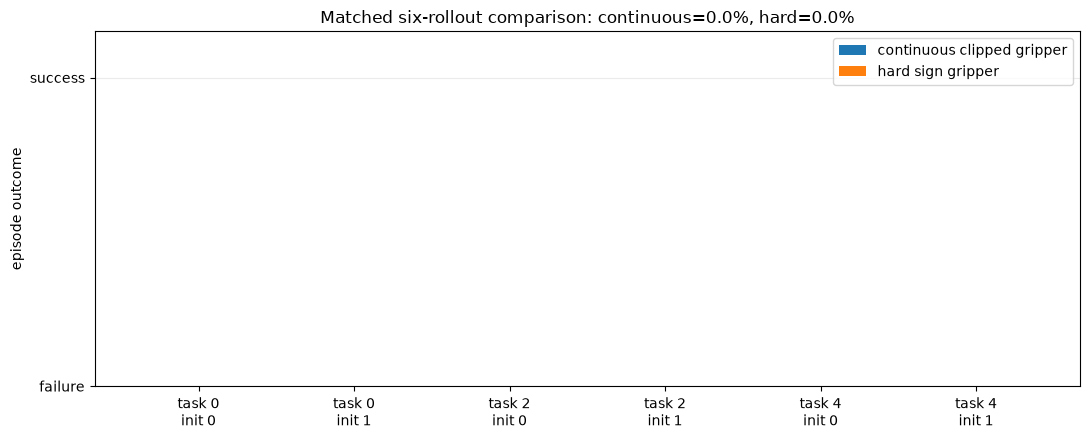

{
  "checkpoint": "/home/ubuntu/ThinkFlow-RDT-1B/output_2/libero_b0_from_oxe20k_v2/checkpoint-20000",
  "action_chunk": 10,
  "seed": 42,
  "threshold_rule": "-1 if gripper < 0 else +1",
  "paired_cases": [
    {
      "task_id": 0,
      "init_state_index": 0,
      "continuous_success": false,
      "thresholded_success": false
    },
    {
      "task_id": 0,
      "init_state_index": 1,
      "continuous_success": false,
      "thresholded_success": false
    },
    {
      "task_id": 2,
      "init_state_index": 0,
      "continuous_success": false,
      "thresholded_success": false
    },
    {
      "task_id": 2,
      "init_state_index": 1,
      "continuous_success": false,
      "thresholded_success": false
    },
    {
      "task_id": 4,
      "init_state_index": 0,
      "continuous_success": false,
      "thresholded_success": false
    },
    {
      "task_id": 4,
      "init_state_index": 1,
      "continuous_success": false,
      "thresholded_success": false
    }
  

task=0 init=1 continuous=0 hard=0


task=2 init=0 continuous=0 hard=0


task=2 init=1 continuous=0 hard=0


task=4 init=0 continuous=0 hard=0


task=4 init=1 continuous=0 hard=0


In [ ]:
from IPython.display import Video, display


def read_jsonl_rows(path: Path) -> list[dict[str, Any]]:
    if not path.is_file():
        return []
    return [
        json.loads(line)
        for line in path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]


continuous_path = (
    RUN_ROOT
    / "rollout_evaluations/checkpoint-20000/libero_object/episodes.jsonl"
)
thresholded_path = HARD_GRIPPER_OUTPUT_DIR / "episodes.jsonl"
continuous_rows = read_jsonl_rows(continuous_path)
thresholded_rows = read_jsonl_rows(thresholded_path)

continuous_by_case = {
    (int(row["task_id"]), int(row["init_state_index"])): row
    for row in continuous_rows
}
thresholded_by_case = {
    (int(row["task_id"]), int(row["init_state_index"])): row
    for row in thresholded_rows
}
expected_cases = [
    (task_id, init_index)
    for task_id in HARD_GRIPPER_TASK_IDS
    for init_index in range(HARD_GRIPPER_EPISODES_PER_TASK)
]
paired_cases = [
    case
    for case in expected_cases
    if case in continuous_by_case and case in thresholded_by_case
]

if not paired_cases:
    print(
        "No paired hard-gripper results yet. Run the rollout cell above; expected output:",
        thresholded_path,
    )
else:
    continuous_success = np.asarray(
        [bool(continuous_by_case[case]["success"]) for case in paired_cases],
        dtype=np.float32,
    )
    thresholded_success = np.asarray(
        [bool(thresholded_by_case[case]["success"]) for case in paired_cases],
        dtype=np.float32,
    )
    labels = [f"task {task_id}\ninit {init_index}" for task_id, init_index in paired_cases]
    x = np.arange(len(paired_cases))
    width = 0.38
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(x - width / 2, continuous_success, width, label="continuous clipped gripper")
    ax.bar(x + width / 2, thresholded_success, width, label="hard sign gripper")
    ax.set_xticks(x, labels)
    ax.set_ylim(0.0, 1.15)
    ax.set_yticks([0.0, 1.0], ["failure", "success"])
    ax.set_ylabel("episode outcome")
    ax.set_title(
        "Matched six-rollout comparison: "
        f"continuous={continuous_success.mean():.1%}, "
        f"hard={thresholded_success.mean():.1%}"
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper right")
    fig.tight_layout()
    comparison_plot = OUTPUT_DIR / "hard_gripper_rollout_comparison.png"
    fig.savefig(comparison_plot, dpi=160)
    plt.show()

    comparison = {
        "checkpoint": str(CHECKPOINT),
        "action_chunk": EXECUTION_HORIZON,
        "seed": 42,
        "threshold_rule": "-1 if gripper < 0 else +1",
        "paired_cases": [
            {
                "task_id": task_id,
                "init_state_index": init_index,
                "continuous_success": bool(continuous_by_case[(task_id, init_index)]["success"]),
                "thresholded_success": bool(thresholded_by_case[(task_id, init_index)]["success"]),
            }
            for task_id, init_index in paired_cases
        ],
        "continuous_success_rate": float(continuous_success.mean()),
        "thresholded_success_rate": float(thresholded_success.mean()),
        "success_rate_delta": float(
            thresholded_success.mean() - continuous_success.mean()
        ),
    }
    comparison_json = OUTPUT_DIR / "hard_gripper_rollout_comparison.json"
    comparison_json.write_text(
        json.dumps(comparison, indent=2) + "\n",
        encoding="utf-8",
    )
    print(json.dumps(comparison, indent=2))
    print("Saved comparison plot:", comparison_plot)
    print("Saved comparison JSON:", comparison_json)

    for case in paired_cases:
        row = thresholded_by_case[case]
        video = row.get("video")
        print(
            f"task={case[0]} init={case[1]} "
            f"continuous={int(bool(continuous_by_case[case]['success']))} "
            f"hard={int(bool(row['success']))}"
        )
        if video and Path(video).is_file():
            display(Video(video, embed=False, width=700))

## Optional cleanup

Uncomment when iterating interactively and you want to release GPU memory.

In [ ]:
# del model, online_siglip
# gc.collect()
# torch.cuda.empty_cache()